In [22]:
import sys, pickle, random
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import networkx as nx
from shapely.geometry import Polygon, MultiPolygon, LineString, MultiLineString, Point, GeometryCollection
from shapely import simplify

# Add ResPlan utils to path
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT / "external" / "ResPlan"))

from resplan_utils import (
    CATEGORY_COLORS, normalize_keys, get_plan_width,
    get_geometries, centroid, geometry_to_mask,
    plot_plan, plan_to_graph, plot_plan_and_graph,
)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.facecolor"] = "white"

print("Ready.")

Ready.


In [31]:
PKL_PATH = PROJECT_ROOT / "data" / "raw" / "ResPlan.pkl"

with open(PKL_PATH, "rb") as f:
    plans = pickle.load(f)

for p in plans:
    normalize_keys(p)

In [32]:
%matplotlib inline

In [33]:
#high corner count plans
high_corner_count_ids = [8246, 15683, 16949, 13113, 2829, 9405, 1715, 13531, 17072]

low_corner_count_ids = [162, 7920, 1324, 10325, 2721, 12677, 5379, 2320, 15787]

In [41]:
def plot_floorplan_simplified_comparison(floorplan_ids, tolerance=0.5, preserve_topology=True):
    def count_polygon_corners(geom):
        if geom is None or not hasattr(geom, "is_empty") or geom.is_empty:
            return 0
        if isinstance(geom, Polygon):
            # Subtract closing vertex repetition.
            return max(len(geom.exterior.coords) - 1, 0)
        if isinstance(geom, MultiPolygon):
            return sum(max(len(poly.exterior.coords) - 1, 0) for poly in geom.geoms if not poly.is_empty)
        return 0

    room_keys = ["living", "bedroom", "bathroom", "kitchen", "balcony", "inner"]

    fig, axes = plt.subplots(2, len(floorplan_ids), figsize=(4 * len(floorplan_ids), 8))

    # When only one ID is provided, keep axes indexing consistent: axes[row, col].
    if len(floorplan_ids) == 1:
        axes = np.array(axes).reshape(2, 1)

    for col, floorplan_id in enumerate(floorplan_ids):
        try:
            plan = normalize_keys(dict(plans[floorplan_id]))

            # Simplify only geometry-like values in the plan dictionary.
            simplified_plan = dict(plan)
            for key, value in plan.items():
                if hasattr(value, "geom_type"):
                    simplified_plan[key] = simplify(
                        value,
                        tolerance=tolerance,
                        preserve_topology=preserve_topology,
                    )

            # Compute corner loss per room type plus total loss.
            corner_loss_by_type = {}
            for key in room_keys:
                before = count_polygon_corners(plan.get(key))
                after = count_polygon_corners(simplified_plan.get(key))
                corner_loss_by_type[key] = before - after

            total_corner_loss = sum(corner_loss_by_type.values())
            loss_summary = ", ".join(
                f"{k}:{v}" for k, v in corner_loss_by_type.items() if v != 0
            ) or "no change"
            print(f"ID {floorplan_id} corner loss by type -> {loss_summary}")

            plot_plan(
                plan,
                ax=axes[0, col],
                title=f"Original - ID: {floorplan_id} - Total corners lost: {total_corner_loss} before: {count_polygon_corners(plan.get('inner'))} after: {count_polygon_corners(simplified_plan.get('inner'))}",
                legend=False,
                tight=False,
            )
            plot_plan(
                simplified_plan,
                ax=axes[1, col],
                title=f"Simplified - ID: {floorplan_id} - Total corners lost: {total_corner_loss} before: {count_polygon_corners(plan.get('inner'))} after: {count_polygon_corners(simplified_plan.get('inner'))}",
                legend=False,
                tight=False,
            )
        except Exception as e:
            axes[0, col].set_title(f"Original - ID: {floorplan_id} - ERROR: {e}")
            axes[0, col].axis("off")
            axes[1, col].set_title(f"Simplified - ID: {floorplan_id} - ERROR")
            axes[1, col].axis("off")

    plt.tight_layout()
    plt.show()

In [35]:
# This cell was previously used for ad-hoc debugging and is no longer needed.

ID 8246 corner loss by type -> living:169, bedroom:259, bathroom:109, balcony:64, inner:174
ID 15683 corner loss by type -> living:2, kitchen:4, balcony:60
ID 16949 corner loss by type -> living:35, bedroom:2, bathroom:15, kitchen:31, inner:31
ID 13113 corner loss by type -> living:26, bathroom:8, kitchen:18, balcony:9
ID 2829 corner loss by type -> living:25, bedroom:17, bathroom:7, kitchen:4, balcony:39, inner:18
ID 9405 corner loss by type -> living:14, bathroom:1, kitchen:6, balcony:10, inner:4
ID 1715 corner loss by type -> living:12, kitchen:4, balcony:5
ID 13531 corner loss by type -> living:26, balcony:6
ID 17072 corner loss by type -> living:8, kitchen:4, inner:2


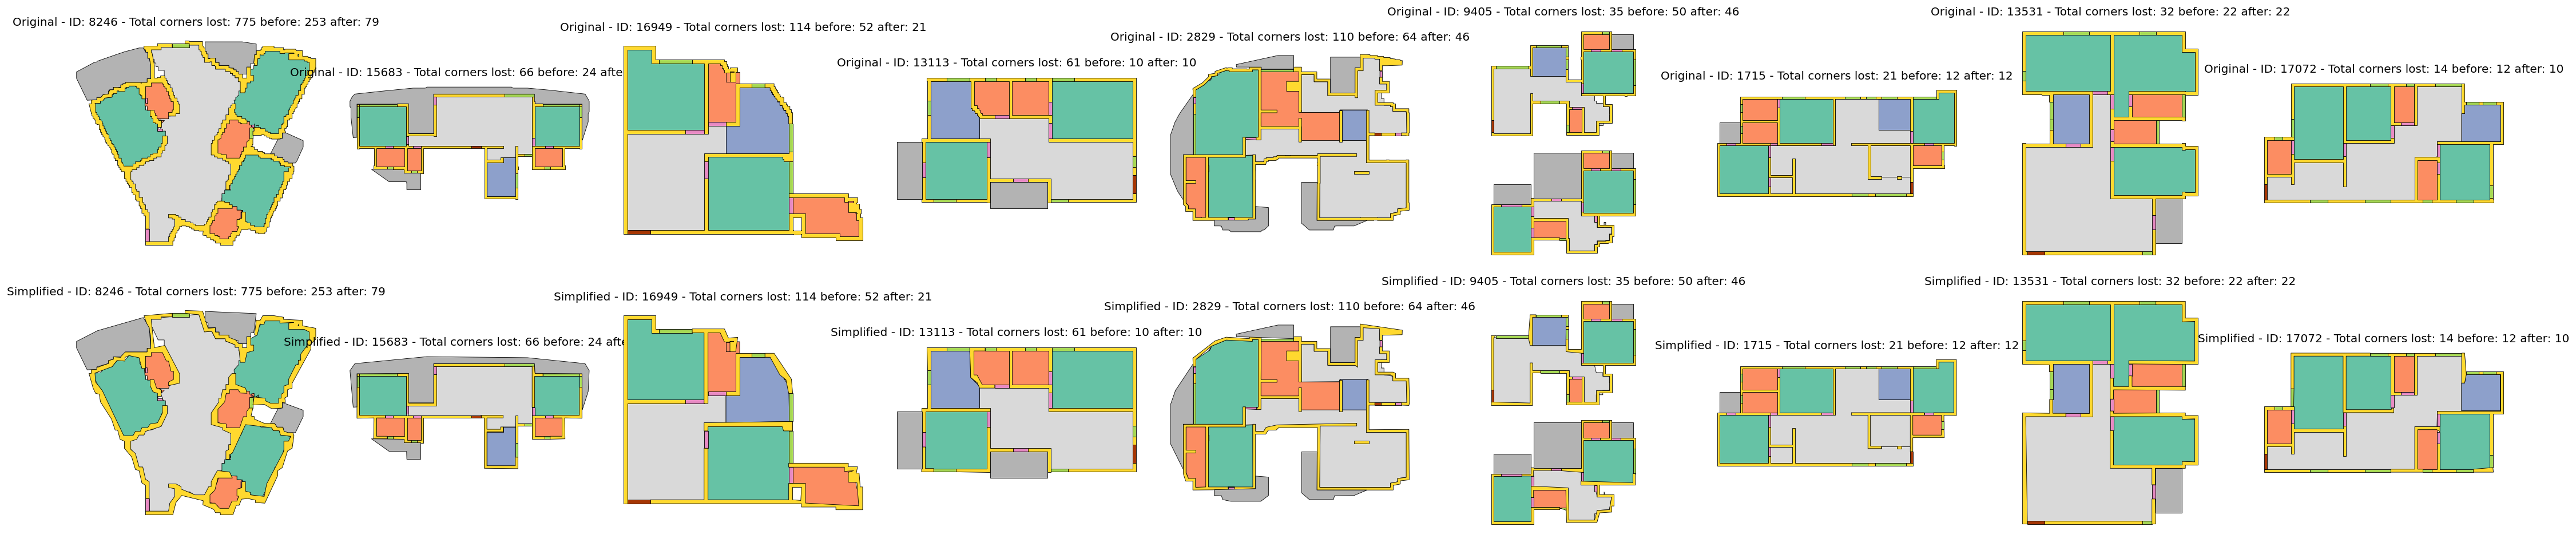

ID 162 corner loss by type -> living:5
ID 7920 corner loss by type -> living:3, kitchen:8, balcony:3
ID 1324 corner loss by type -> living:6, kitchen:2, balcony:17
ID 10325 corner loss by type -> living:1, kitchen:3, balcony:15
ID 2721 corner loss by type -> living:4, kitchen:8
ID 12677 corner loss by type -> no change
ID 5379 corner loss by type -> kitchen:2, balcony:4
ID 2320 corner loss by type -> living:4, kitchen:6, balcony:11
ID 15787 corner loss by type -> balcony:2


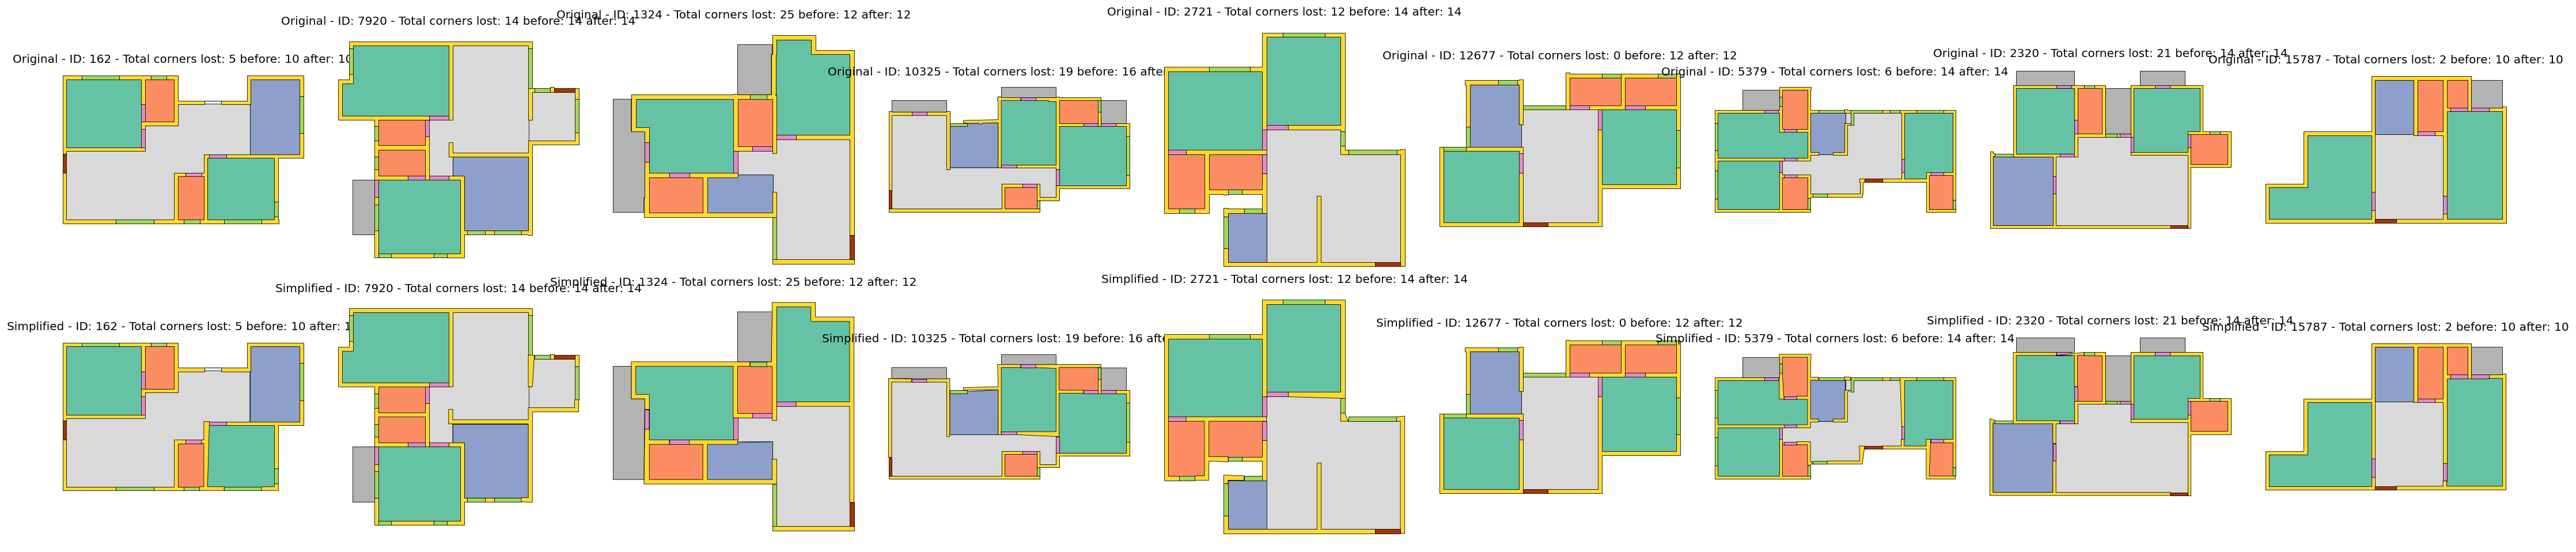

In [42]:
plot_floorplan_simplified_comparison(high_corner_count_ids, tolerance=2.0)
plot_floorplan_simplified_comparison(low_corner_count_ids, tolerance=2.0)